### 1.Load and Save the Dataset

In [1]:
import yfinance as yf
import pandas as pd
import time

stocks = {
    "AAPL": "Technology",
    "MSFT": "Technology",
    "NVDA": "Technology",
    "TSLA": "Technology",
    "JPM": "Financial",
    "GS": "Financial",
    "XOM": "Energy",
    "CVX": "Energy",
    "PFE": "Healthcare",
    "JNJ": "Healthcare"
}

all_frames = []

for ticker, sector in stocks.items():
    print(f"Downloading {ticker}")

    df = yf.download(
        ticker,
        start="2020-01-01",
        end="2025-01-01",
        progress=False
    )

    if df is None or df.empty:
        print(f"Skipped {ticker}")
        continue

    # FIX: Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    df = df.reset_index()

    # Normalize column names (yfinance sometimes uses 'Price' as top level)
    df.columns = [str(c).strip() for c in df.columns]

    df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

    df["Stock"] = ticker
    df["Sector"] = sector

    all_frames.append(df)
    time.sleep(0.5)

stock_df = pd.concat(all_frames, axis=0, ignore_index=True)

print(stock_df.head())
print(stock_df.columns)

# Save cleanly
stock_df.to_csv("stocks.csv", index=False)

        Date       Open       High        Low      Close     Volume Stock  \
0 2020-01-02  71.344069  72.394101  71.091199  72.333893  135480400  AAPL   
1 2020-01-03  71.563190  72.389242  71.406651  71.630623  146322800  AAPL   
2 2020-01-06  70.753999  72.239927  70.503531  72.201393  118387200  AAPL   
3 2020-01-07  72.211072  72.466353  71.642712  71.861870  108872000  AAPL   
4 2020-01-08  71.565621  73.318877  71.565621  73.017838  132079200  AAPL   

       Sector  
0  Technology  
1  Technology  
2  Technology  
3  Technology  
4  Technology  
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Stock', 'Sector'], dtype='object')


## DATA CLEANING

#### 1.Null Check

In [2]:
stock_df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Stock     0
Sector    0
dtype: int64

### 2.Duplicate Check

In [3]:
stock_df.duplicated().sum()

np.int64(0)

### 3.Sort Values firstly by **Stocks** and then **Date** Column

In [4]:
stock_df = stock_df.sort_values(["Stock", "Date"])
df.head()

,Date,Open,High,Low,Close,Volume,Stock,Sector
0,2020-01-02,121.853448,121.978759,121.193522,121.936989,5777000,JNJ,Healthcare
1,2020-01-03,119.873608,121.435720,119.455930,120.525185,5752400,JNJ,Healthcare
2,2020-01-06,120.291314,120.458383,119.330660,120.374855,7731300,JNJ,Healthcare
3,2020-01-07,120.299658,121.502573,118.102680,121.109955,7382900,JNJ,Healthcare
4,2020-01-08,121.018055,121.945301,120.040689,121.093246,6605800,JNJ,Healthcare


### 4.Validate Price Logic


In [5]:
invalid_prices = stock_df[
    (stock_df["High"] < stock_df["Low"]) |
    (stock_df["Open"] > stock_df["High"]) |
    (stock_df["Open"] < stock_df["Low"])  |
    (stock_df["Close"] > stock_df["High"])|
    (stock_df["Close"] < stock_df["Low"])
]
print(f"Invalid price rows: {len(invalid_prices)}")

Invalid price rows: 0


### 5.Remove Zero and Negative Price

In [6]:
stock_df = stock_df[
    (stock_df["Open"]  > 0) &
    (stock_df["High"]  > 0) &
    (stock_df["Low"]   > 0) &
    (stock_df["Close"] > 0) &
    (stock_df["Volume"] >= 0)
]

### 6.Remove Outliers

In [7]:
from scipy import stats

stock_df["z_close"] = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: stats.zscore(x, nan_policy="omit"))
)
before = len(stock_df)
stock_df = stock_df[stock_df["z_close"].abs() <= 3]
stock_df = stock_df.drop(columns=["z_close"])
print(f"Outliers removed: {before - len(stock_df)}")

Outliers removed: 10


## FEATURE ENGINEERING

### 1.Calculate Daily Returns

In [8]:
stock_df["Daily_Return"] = (
    stock_df.groupby("Stock")["Close"]
    .pct_change() * 100
).round(4)

In [9]:
stock_df.head(10)

,Date,Open,High,Low,Close,Volume,Stock,Sector,Daily_Return
0,2020-01-02,71.344069,72.394101,71.091199,72.333893,135480400,AAPL,Technology,NaN
1,2020-01-03,71.563190,72.389242,71.406651,71.630623,146322800,AAPL,Technology,-0.9723
2,2020-01-06,70.753999,72.239927,70.503531,72.201393,118387200,AAPL,Technology,0.7968
3,2020-01-07,72.211072,72.466353,71.642712,71.861870,108872000,AAPL,Technology,-0.4702
4,2020-01-08,71.565621,73.318877,71.565621,73.017838,132079200,AAPL,Technology,1.6086
5,2020-01-09,73.993187,74.761442,73.742727,74.568779,170108400,AAPL,Technology,2.1241
6,2020-01-10,74.802410,75.300934,74.236454,74.737381,140644800,AAPL,Technology,0.2261
7,2020-01-13,75.052848,76.360564,74.934836,76.334068,121532000,AAPL,Technology,2.1364
8,2020-01-14,76.271463,76.480986,75.180495,75.303314,161954400,AAPL,Technology,-1.3503
9,2020-01-15,75.103440,75.982475,74.549522,74.980614,121923600,AAPL,Technology,-0.4285


### 2.Calculate 7 Day and 30 Day Moving Averages

In [10]:
stock_df["MA_7"]  = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: x.rolling(7).mean())
).round(4)

stock_df["MA_30"] = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: x.rolling(30).mean())
).round(4)

In [11]:
stock_df.head(10)

,Date,Open,High,Low,Close,Volume,Stock,Sector,Daily_Return,MA_7,MA_30
0,2020-01-02,71.344069,72.394101,71.091199,72.333893,135480400,AAPL,Technology,NaN,NaN,NaN
1,2020-01-03,71.563190,72.389242,71.406651,71.630623,146322800,AAPL,Technology,-0.9723,NaN,NaN
2,2020-01-06,70.753999,72.239927,70.503531,72.201393,118387200,AAPL,Technology,0.7968,NaN,NaN
3,2020-01-07,72.211072,72.466353,71.642712,71.861870,108872000,AAPL,Technology,-0.4702,NaN,NaN
4,2020-01-08,71.565621,73.318877,71.565621,73.017838,132079200,AAPL,Technology,1.6086,NaN,NaN
5,2020-01-09,73.993187,74.761442,73.742727,74.568779,170108400,AAPL,Technology,2.1241,NaN,NaN
6,2020-01-10,74.802410,75.300934,74.236454,74.737381,140644800,AAPL,Technology,0.2261,72.9074,NaN
7,2020-01-13,75.052848,76.360564,74.934836,76.334068,121532000,AAPL,Technology,2.1364,73.4789,NaN
8,2020-01-14,76.271463,76.480986,75.180495,75.303314,161954400,AAPL,Technology,-1.3503,74.0035,NaN
9,2020-01-15,75.103440,75.982475,74.549522,74.980614,121923600,AAPL,Technology,-0.4285,74.4006,NaN


### 3.Calculate Price Range

In [12]:
stock_df["Price_Range"] = (
    stock_df["High"] -
    stock_df["Low"]
)
stock_df.head(10)

,Date,Open,High,Low,Close,Volume,Stock,Sector,Daily_Return,MA_7,MA_30,Price_Range
0,2020-01-02,71.344069,72.394101,71.091199,72.333893,135480400,AAPL,Technology,NaN,NaN,NaN,1.302902
1,2020-01-03,71.563190,72.389242,71.406651,71.630623,146322800,AAPL,Technology,-0.9723,NaN,NaN,0.982591
2,2020-01-06,70.753999,72.239927,70.503531,72.201393,118387200,AAPL,Technology,0.7968,NaN,NaN,1.736396
3,2020-01-07,72.211072,72.466353,71.642712,71.861870,108872000,AAPL,Technology,-0.4702,NaN,NaN,0.823641
4,2020-01-08,71.565621,73.318877,71.565621,73.017838,132079200,AAPL,Technology,1.6086,NaN,NaN,1.753256
5,2020-01-09,73.993187,74.761442,73.742727,74.568779,170108400,AAPL,Technology,2.1241,NaN,NaN,1.018714
6,2020-01-10,74.802410,75.300934,74.236454,74.737381,140644800,AAPL,Technology,0.2261,72.9074,NaN,1.064481
7,2020-01-13,75.052848,76.360564,74.934836,76.334068,121532000,AAPL,Technology,2.1364,73.4789,NaN,1.425728
8,2020-01-14,76.271463,76.480986,75.180495,75.303314,161954400,AAPL,Technology,-1.3503,74.0035,NaN,1.300491
9,2020-01-15,75.103440,75.982475,74.549522,74.980614,121923600,AAPL,Technology,-0.4285,74.4006,NaN,1.432953


### 4.Calculate Volatility

In [13]:
stock_df["Volatility_7"] = (
    stock_df.groupby("Stock")["Daily_Return"]
    .transform(
        lambda x: x.rolling(7).std()
    )
)
stock_df.head(10)

,Date,Open,High,Low,Close,Volume,Stock,Sector,Daily_Return,MA_7,MA_30,Price_Range,Volatility_7
0,2020-01-02,71.344069,72.394101,71.091199,72.333893,135480400,AAPL,Technology,NaN,NaN,NaN,1.302902,NaN
1,2020-01-03,71.563190,72.389242,71.406651,71.630623,146322800,AAPL,Technology,-0.9723,NaN,NaN,0.982591,NaN
2,2020-01-06,70.753999,72.239927,70.503531,72.201393,118387200,AAPL,Technology,0.7968,NaN,NaN,1.736396,NaN
3,2020-01-07,72.211072,72.466353,71.642712,71.861870,108872000,AAPL,Technology,-0.4702,NaN,NaN,0.823641,NaN
4,2020-01-08,71.565621,73.318877,71.565621,73.017838,132079200,AAPL,Technology,1.6086,NaN,NaN,1.753256,NaN
5,2020-01-09,73.993187,74.761442,73.742727,74.568779,170108400,AAPL,Technology,2.1241,NaN,NaN,1.018714,NaN
6,2020-01-10,74.802410,75.300934,74.236454,74.737381,140644800,AAPL,Technology,0.2261,72.9074,NaN,1.064481,NaN
7,2020-01-13,75.052848,76.360564,74.934836,76.334068,121532000,AAPL,Technology,2.1364,73.4789,NaN,1.425728,1.243224
8,2020-01-14,76.271463,76.480986,75.180495,75.303314,161954400,AAPL,Technology,-1.3503,74.0035,NaN,1.300491,1.336644
9,2020-01-15,75.103440,75.982475,74.549522,74.980614,121923600,AAPL,Technology,-0.4285,74.4006,NaN,1.432953,1.404125


In [14]:
stock_df.to_csv("stock_processed.csv", index=False)


## Exploratory Data Analysis

### Number of Stocks Per Sector

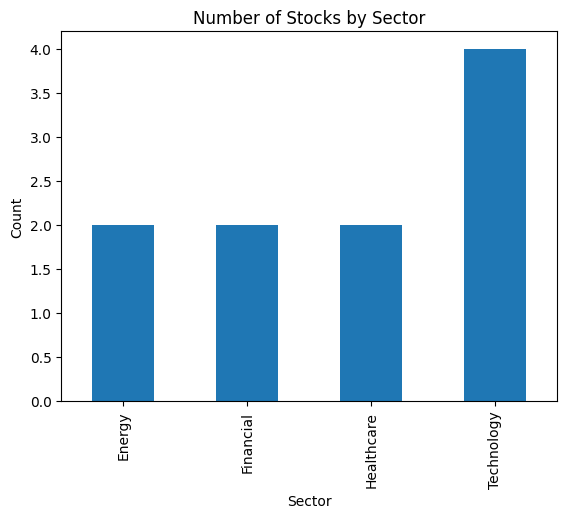

In [15]:
stock_df.groupby("Sector")["Stock"].nunique()
import seaborn as sns
import matplotlib.pyplot as plt

stock_df.groupby("Sector")["Stock"].nunique().plot(kind="bar")

plt.title("Number of Stocks by Sector")
plt.ylabel("Count")
plt.show()

### Stock Price Trend Analysis

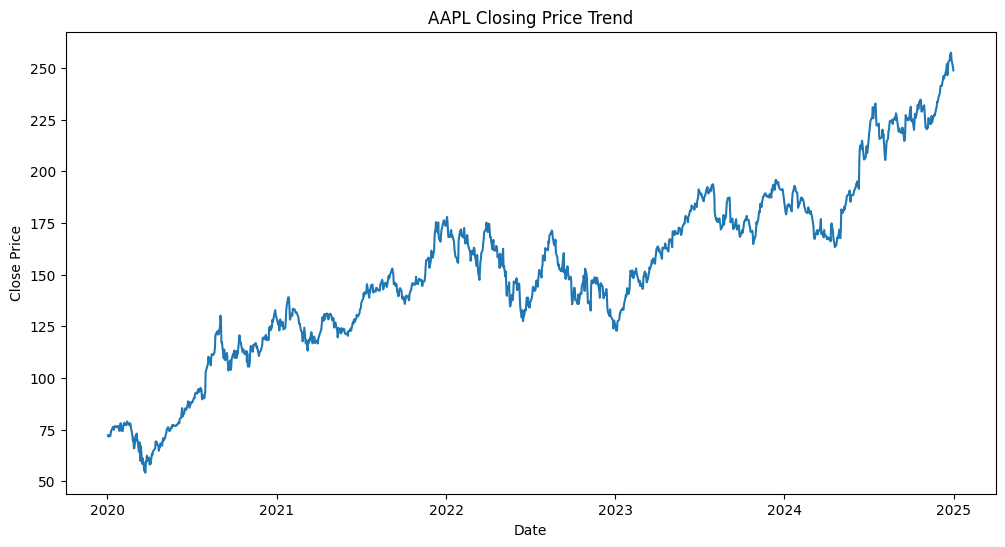

In [16]:
apple = stock_df[stock_df["Stock"] == "AAPL"]

plt.figure(figsize=(12,6))
plt.plot(apple["Date"], apple["Close"])

plt.title("AAPL Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

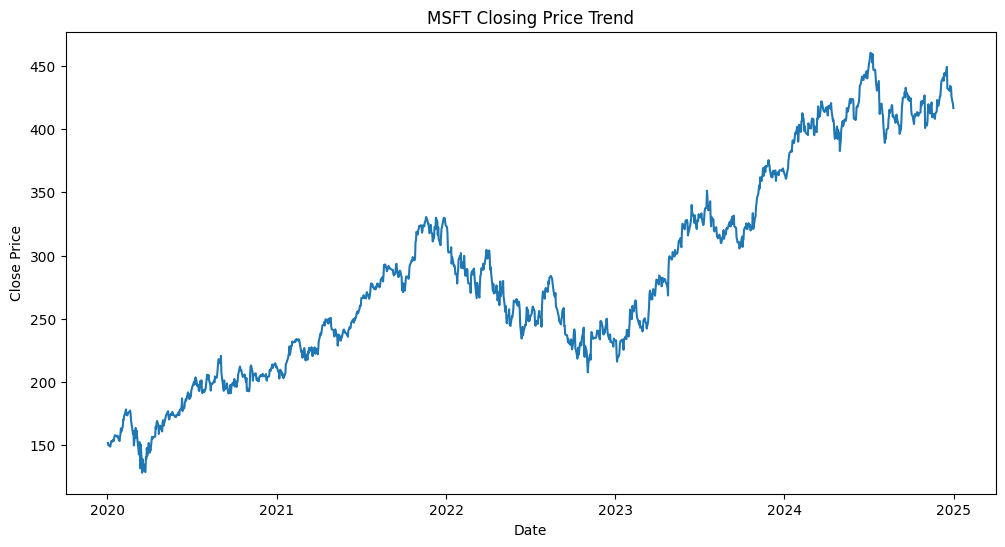

In [17]:
microsoft = stock_df[stock_df["Stock"] == "MSFT"]

plt.figure(figsize=(12,6))
plt.plot(microsoft["Date"], microsoft["Close"])

plt.title("MSFT Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

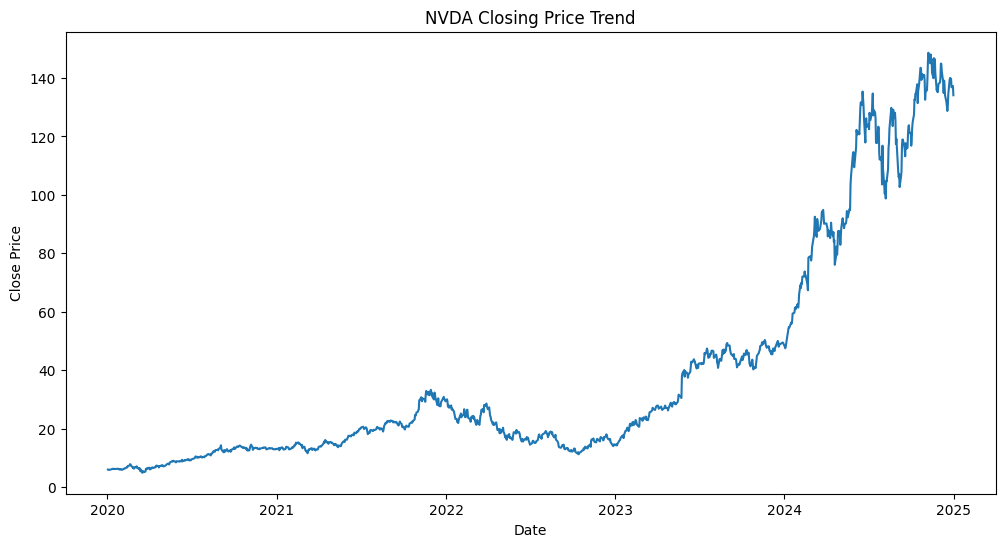

In [18]:
nvidia=stock_df[stock_df["Stock"] == "NVDA"]

plt.figure(figsize=(12,6))
plt.plot(nvidia["Date"], nvidia["Close"])

plt.title("NVDA Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

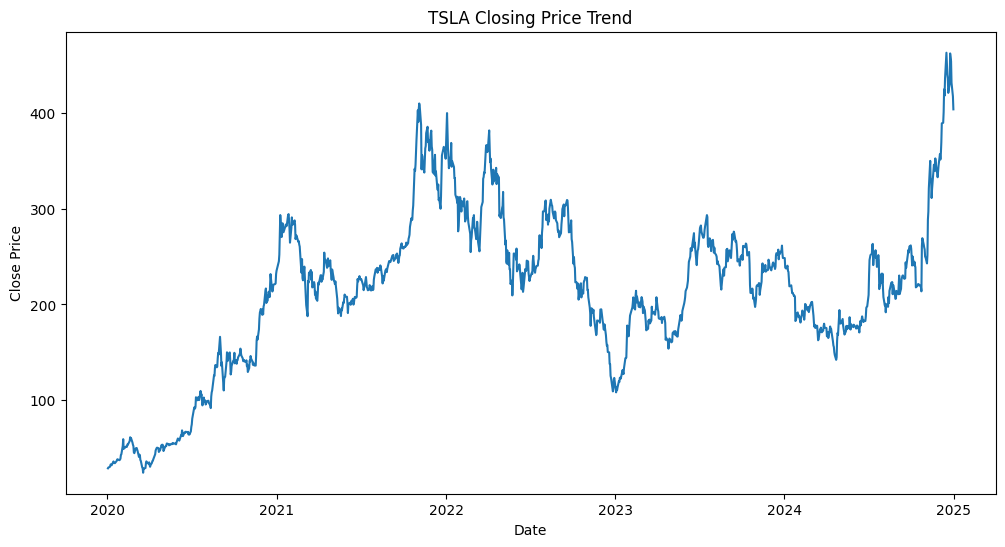

In [19]:
tesla = stock_df[stock_df["Stock"] == "TSLA"]

plt.figure(figsize=(12,6))
plt.plot(tesla["Date"], tesla["Close"])

plt.title("TSLA Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

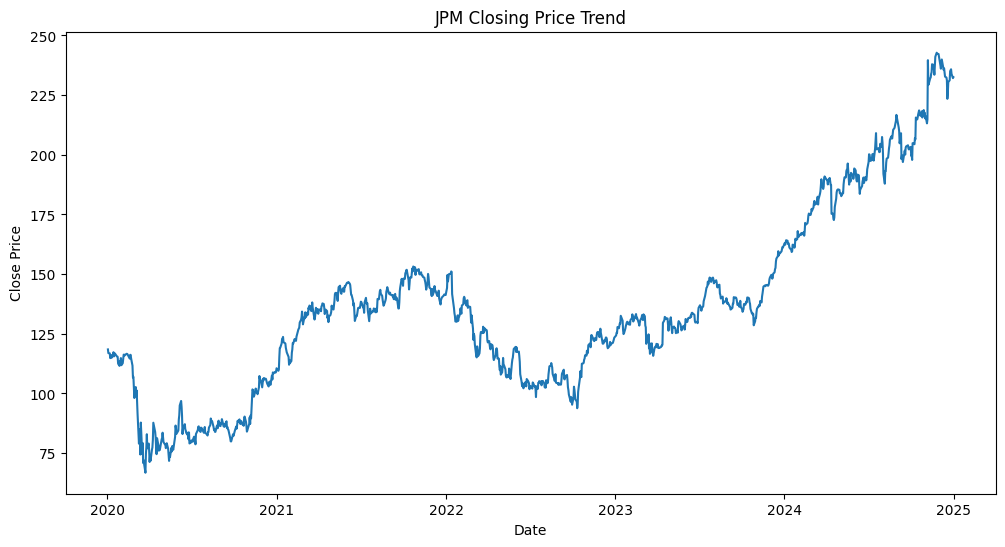

In [20]:
jpmorgan = stock_df[stock_df["Stock"] == "JPM"]

plt.figure(figsize=(12,6))
plt.plot(jpmorgan["Date"], jpmorgan["Close"])

plt.title("JPM Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

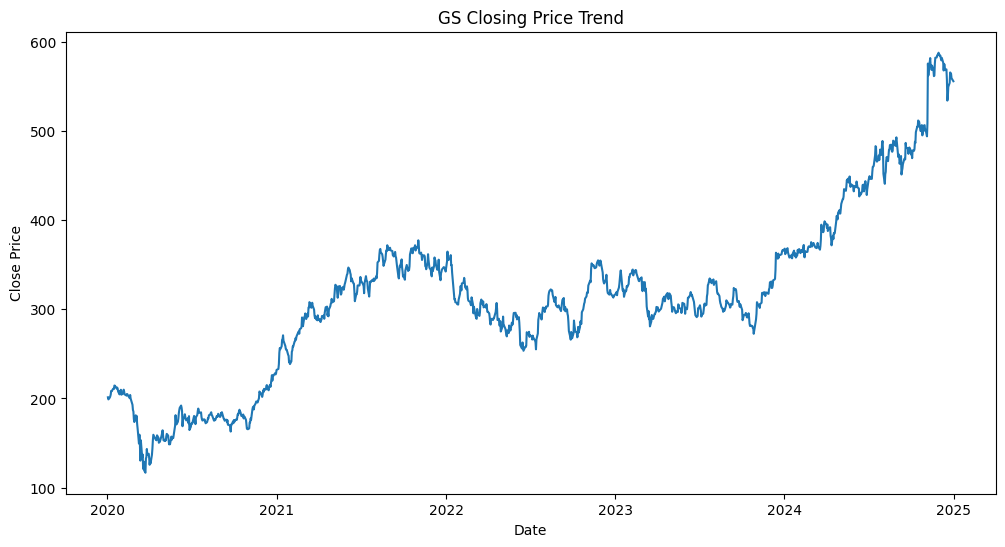

In [21]:
goldmansachs = stock_df[stock_df["Stock"] == "GS"]

plt.figure(figsize=(12,6))
plt.plot(goldmansachs["Date"], goldmansachs["Close"])

plt.title("GS Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

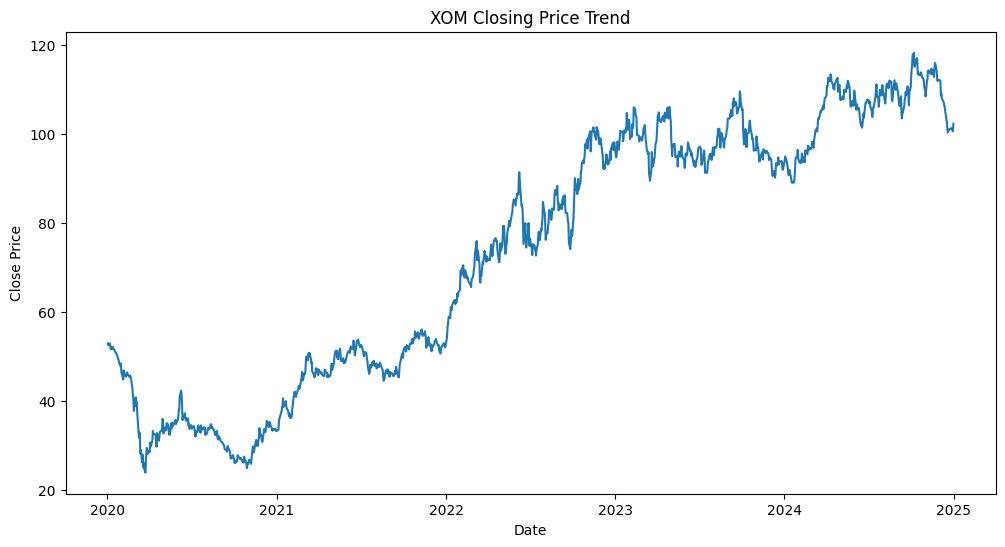

In [22]:
xom = stock_df[stock_df["Stock"] == "XOM"]

plt.figure(figsize=(12,6))
plt.plot(xom["Date"], xom["Close"])

plt.title("XOM Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

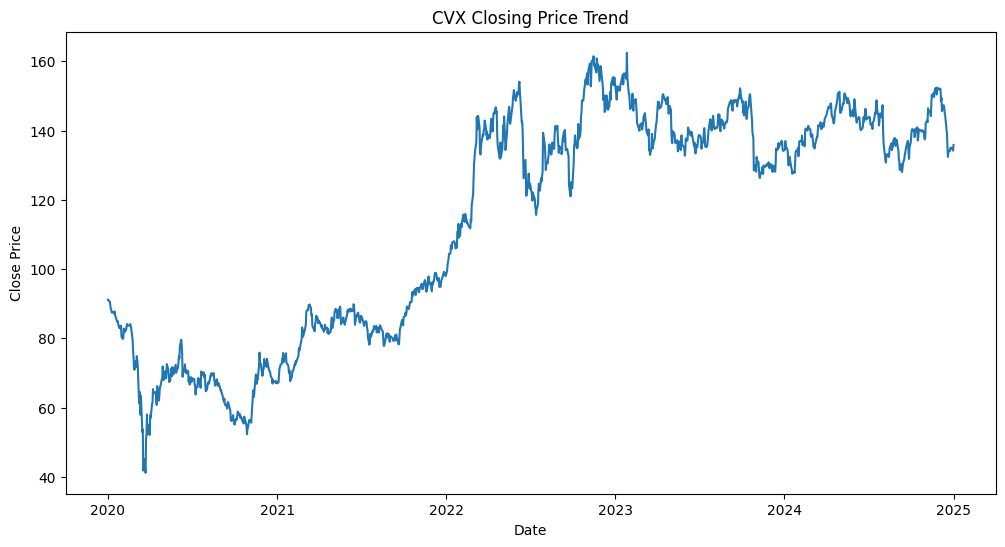

In [23]:
cvx= stock_df[stock_df["Stock"] == "CVX"]

plt.figure(figsize=(12,6))
plt.plot(cvx["Date"], cvx["Close"])

plt.title("CVX Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

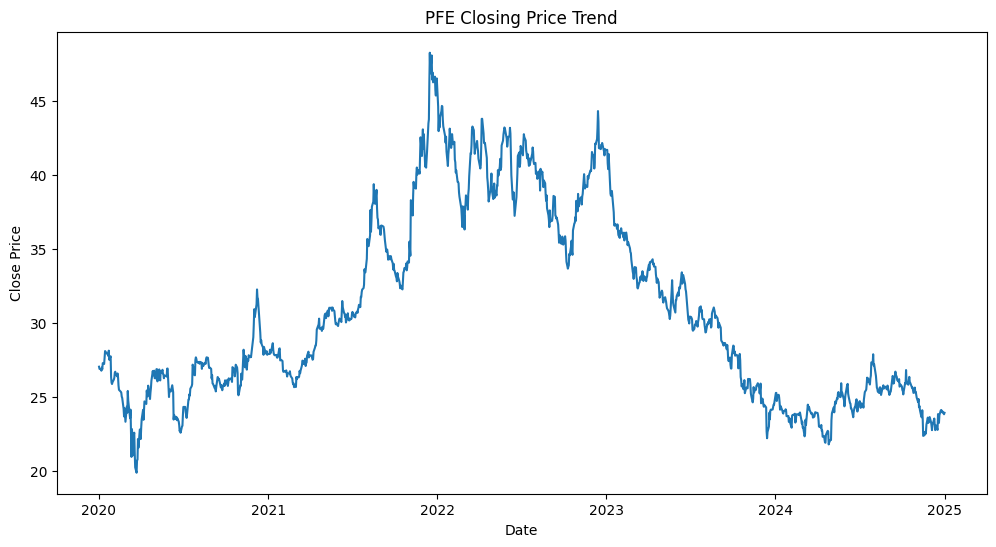

In [24]:
pfe = stock_df[stock_df["Stock"] == "PFE"]

plt.figure(figsize=(12,6))
plt.plot(pfe["Date"], pfe["Close"])

plt.title("PFE Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

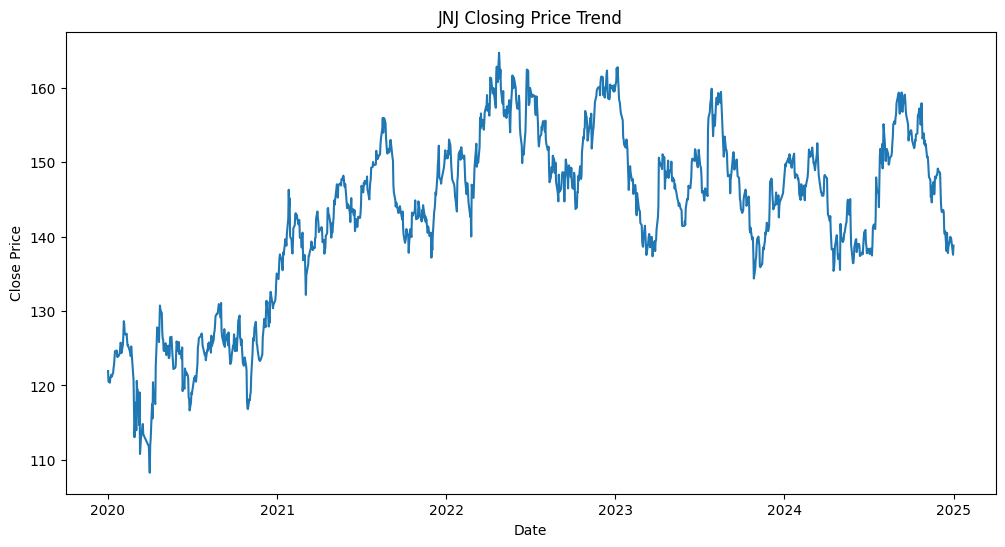

In [25]:
jng = stock_df[stock_df["Stock"] == "JNJ"]

plt.figure(figsize=(12,6))
plt.plot(jng["Date"], jng["Close"])

plt.title("JNJ Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

### Trading Volume Analysis

In [26]:
volume_analysis = (
    stock_df.groupby("Stock")["Volume"]
    .mean()
    .sort_values(ascending=False)
)

print(volume_analysis)

Stock
NVDA    4.467728e+08
TSLA    1.255323e+08
AAPL    9.057103e+07
PFE     3.164482e+07
MSFT    2.863777e+07
XOM     2.239011e+07
JPM     1.312394e+07
CVX     9.924249e+06
JNJ     8.089609e+06
GS      2.698083e+06
Name: Volume, dtype: float64


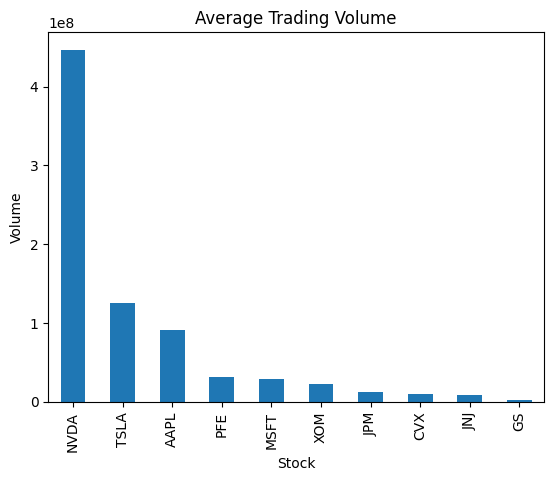

In [27]:
volume_analysis.plot(kind="bar")

plt.title("Average Trading Volume")
plt.ylabel("Volume")
plt.show()

### Daily Return Distribution

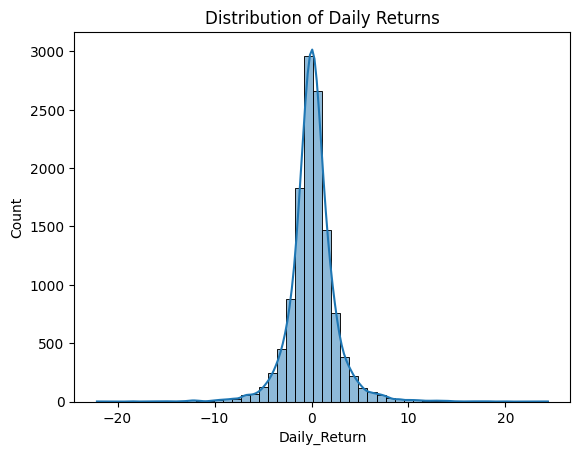

In [28]:
sns.histplot(
    stock_df["Daily_Return"],
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.show()

### Sector-wise Return Analysis

Sector
Technology    0.205411
Financial     0.088553
Energy        0.066480
Healthcare    0.010759
Name: Daily_Return, dtype: float64


<Axes: xlabel='Sector'>

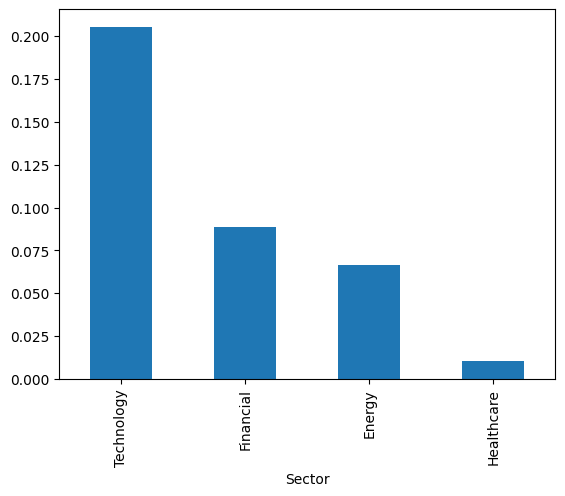

In [29]:
sector_return=stock_df.groupby("Sector")["Daily_Return"].mean().sort_values(ascending=False)
print(sector_return)
sector_return.plot(kind="bar")

### Volatility Analysis

In [30]:
risk = (
    stock_df.groupby("Stock")["Volatility_7"]
    .mean()
    .sort_values(ascending=False)
)

print(risk)

Stock
TSLA    3.772451
NVDA    3.090071
XOM     1.894380
CVX     1.789919
AAPL    1.742721
GS      1.737428
MSFT    1.678463
JPM     1.640495
PFE     1.527242
JNJ     0.982404
Name: Volatility_7, dtype: float64


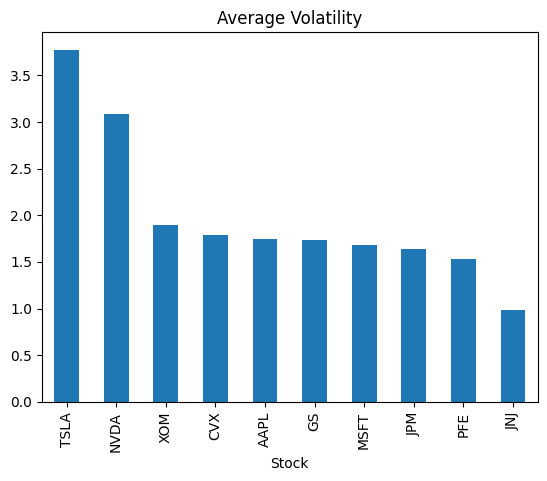

In [31]:
risk.plot(kind="bar")
plt.title("Average Volatility")
plt.show()

### Top GAINERS and LOSERS

In [32]:
top_gainers = (
    stock_df.groupby("Stock")["Daily_Return"]
    .mean()
    .sort_values(ascending=False)
)
print("TOP GAINERS:",top_gainers.head())
print("TOP LOSERS:",top_gainers.tail())

TOP GAINERS: Stock
NVDA    0.304986
TSLA    0.299741
AAPL    0.118212
GS      0.102529
MSFT    0.098782
Name: Daily_Return, dtype: float64
TOP LOSERS: Stock
XOM    0.075910
JPM    0.074576
CVX    0.057050
JNJ    0.016367
PFE    0.005192
Name: Daily_Return, dtype: float64


### Moving Average Analysis

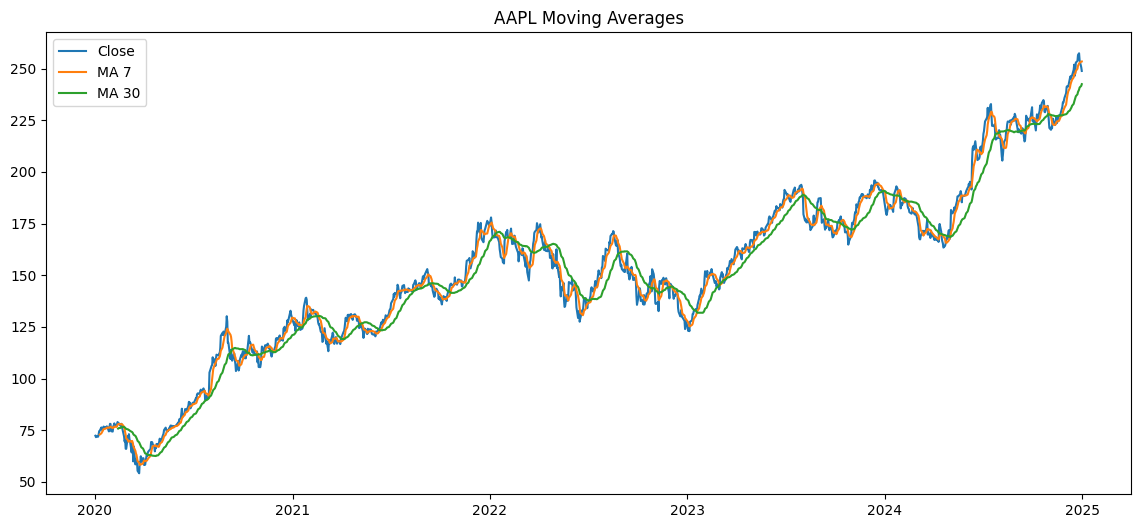

In [33]:
apple = stock_df[stock_df["Stock"] == "AAPL"]

plt.figure(figsize=(14,6))

plt.plot(apple["Date"], apple["Close"], label="Close")
plt.plot(apple["Date"], apple["MA_7"], label="MA 7")
plt.plot(apple["Date"], apple["MA_30"], label="MA 30")

plt.legend()
plt.title("AAPL Moving Averages")
plt.show()

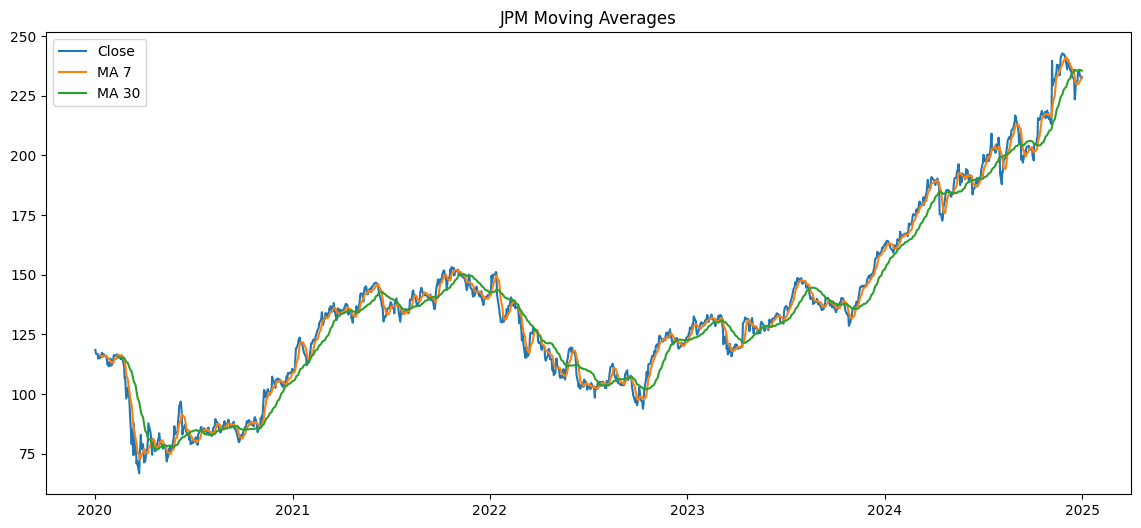

In [34]:
jpmorgan = stock_df[stock_df["Stock"] == "JPM"]

plt.figure(figsize=(14,6))

plt.plot(jpmorgan["Date"], jpmorgan["Close"], label="Close")
plt.plot(jpmorgan["Date"], jpmorgan["MA_7"], label="MA 7")
plt.plot(jpmorgan["Date"], jpmorgan["MA_30"], label="MA 30")

plt.legend()
plt.title("JPM Moving Averages")
plt.show()

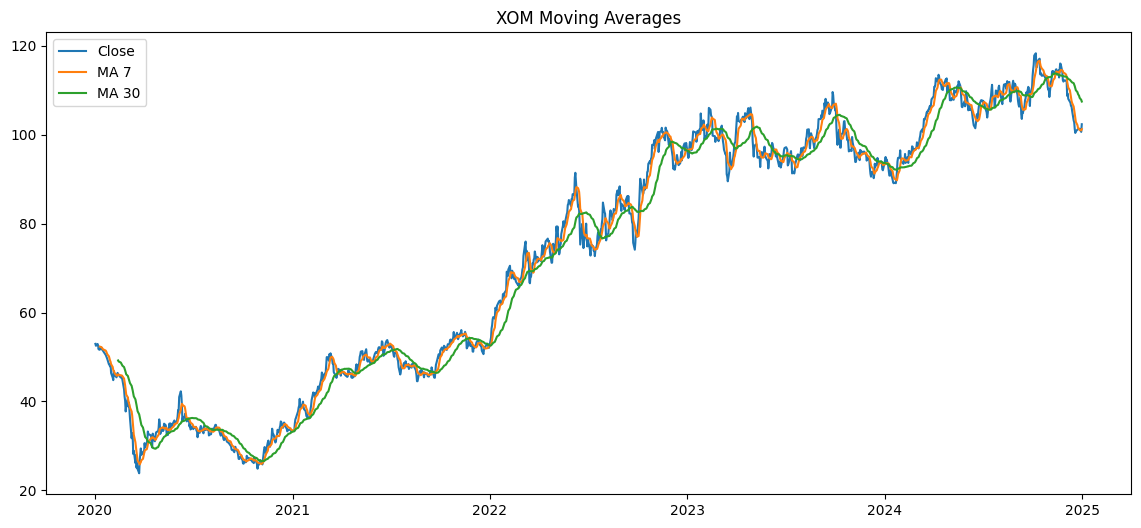

In [35]:
xom = stock_df[stock_df["Stock"] == "XOM"]

plt.figure(figsize=(14,6))

plt.plot(xom["Date"], xom["Close"], label="Close")
plt.plot(xom["Date"], xom["MA_7"], label="MA 7")
plt.plot(xom["Date"], xom["MA_30"], label="MA 30")

plt.legend()
plt.title("XOM Moving Averages")
plt.show()

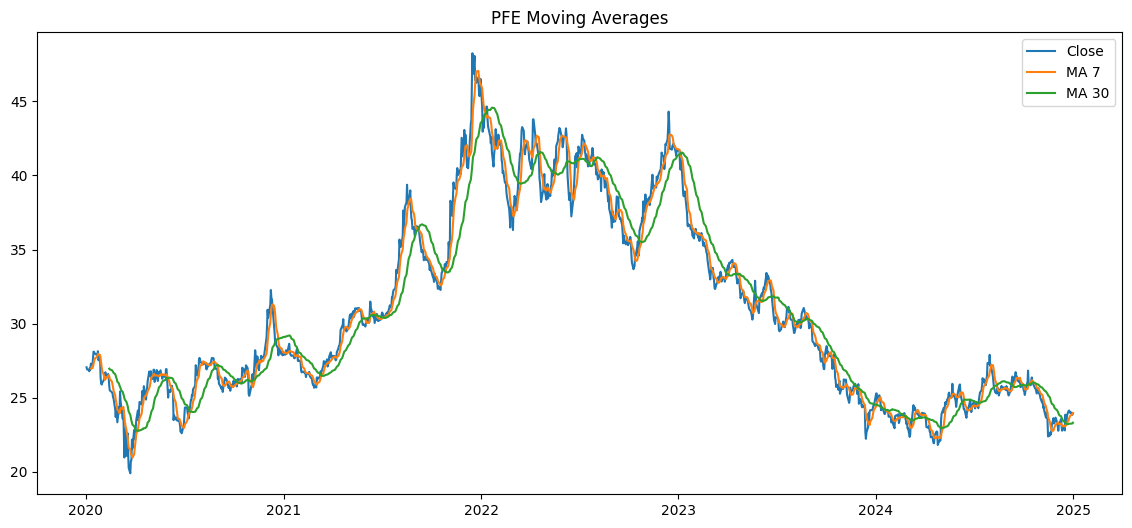

In [36]:
pfe = stock_df[stock_df["Stock"] == "PFE"]

plt.figure(figsize=(14,6))

plt.plot(pfe["Date"], pfe["Close"], label="Close")
plt.plot(pfe["Date"], pfe["MA_7"], label="MA 7")
plt.plot(pfe["Date"], pfe["MA_30"], label="MA 30")

plt.legend()
plt.title("PFE Moving Averages")
plt.show()

### Correlation Analysis

In [37]:
corr = stock_df[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "Daily_Return",
        "Price_Range",
        "Volatility_7"
    ]
].corr()

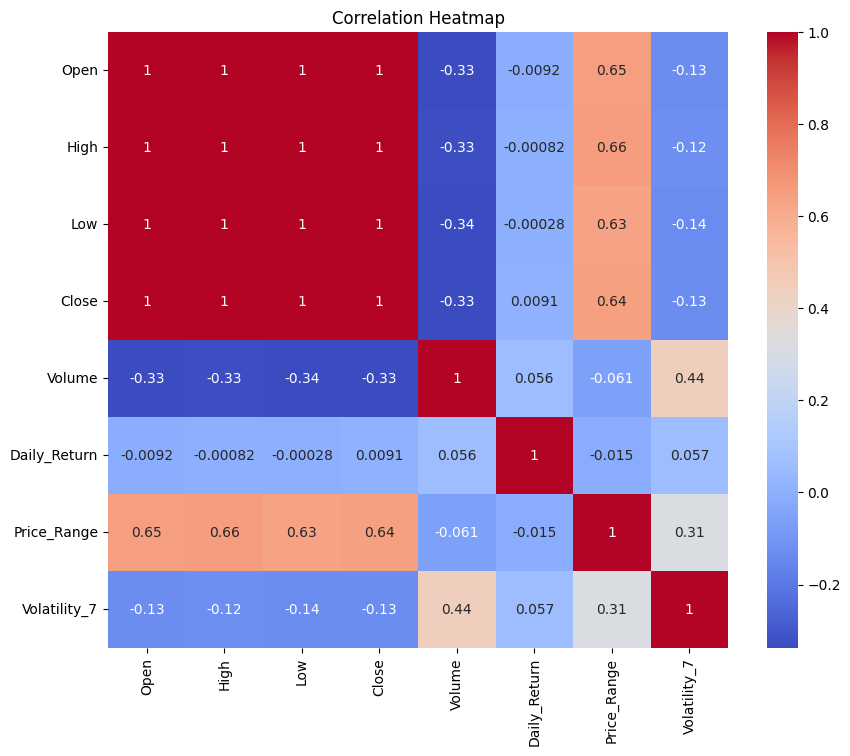

In [38]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Sector Wise Volatility

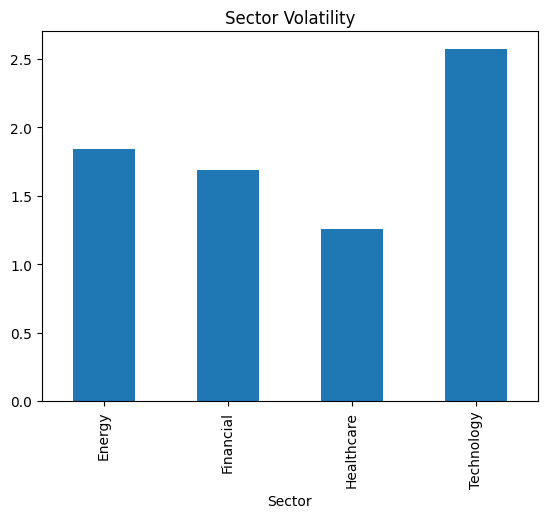

In [39]:
sector_risk = (
    stock_df.groupby("Sector")["Volatility_7"]
    .mean()
)

sector_risk.plot(kind="bar")

plt.title("Sector Volatility")
plt.show()

### Price Range Analysis

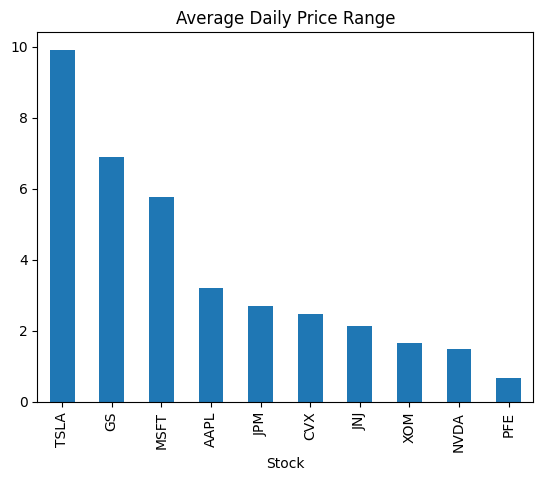

In [40]:
price_range = (
    stock_df.groupby("Stock")["Price_Range"]
    .mean()
    .sort_values(ascending=False)
)

price_range.plot(kind="bar")

plt.title("Average Daily Price Range")
plt.show()